In [7]:
using Revise, Plots
include("../src/SOC_Controller.jl")

Main.SoCController

In [8]:
# Define simulation time-scale/steps
Δt = 2.5 # seconds
dt_min = Δt/(60) # convert ΔT from seconds to minutes
dt_hrs = Δt/(60*60) # convert ΔT from seconds to hours
T_begin = 9.0; # hours
T_end = 12.0; # hours 
ts_hrs = T_begin:dt_hrs:T_end # hours
ts_min = T_begin*60:dt_min:T_end*60

540.0:0.041666666666666664:720.0

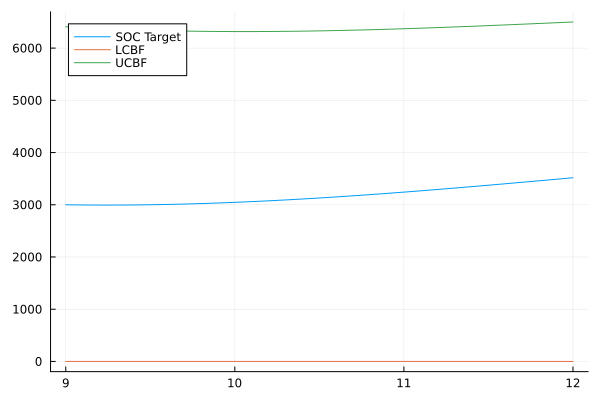

In [9]:
# Generate SOC_Target Profile
soc_begin = 3000
soc_end = 3500
lcbf = SoCController.compute_lcbf(ts_hrs, dt_hrs);
ucbf = SoCController.compute_ucbf(ts_hrs, dt_hrs);
soc_target = SoCController.generate_SOC_target(lcbf, ucbf,  soc_begin, soc_end, ts_hrs, dt_hrs);
plot(ts_hrs, soc_target, label="SOC Target")
plot!(ts_hrs, lcbf, label="LCBF")
plot!(ts_hrs,ucbf, label="UCBF")

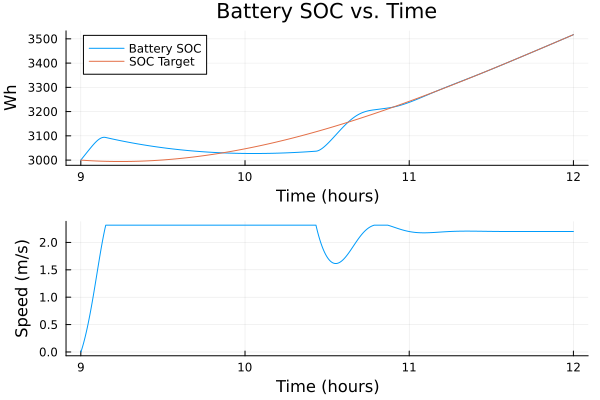

In [10]:
# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label=false, ylabel="Speed (m/s)", xlabel="Time (hours)", legend=:topright)

plot(socplot, speed_plot, layout=(2,1))

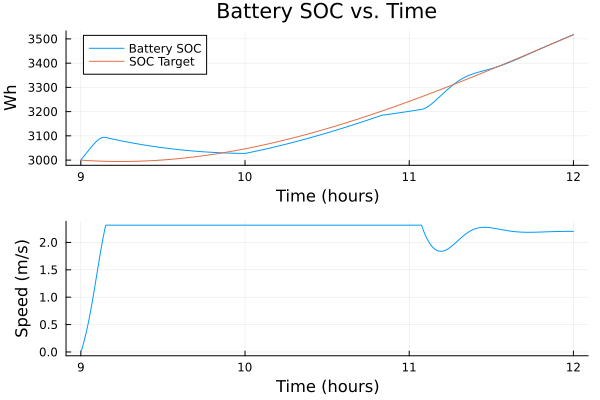

In [16]:
# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    if 600 <= t <= 650
        push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60) + 0.1)
    else
        push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
    end
end

socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label=false, ylabel="Speed (m/s)", xlabel="Time (hours)", legend=:topright)

plot(socplot, speed_plot, layout=(2,1))

In [13]:
ts_min

540.0:0.041666666666666664:720.0